# COT inference

Conditional Wasserstein-2 distance estimation via smooth marginal density estimation.

TODO:
* Check the clip function.
* Check the sampler.

In [1]:
# Library
!pip install pywavelets
!pip install pot # used for dy >= 2

import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
import pywt
from scipy.linalg import sqrtm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 21.1 MB/s eta 0:00:00


## Estimation

In [2]:
#@title Wavelet-based estimator

# """
# Smooth Conditional Wasserstein-2 distance via wavelet density estimators.

# Wavelet density estimator): implemented by
#   (i) [?]binning data on a dy+dz dimensional dyadic grid,
#   (ii) applying a multilevel wavelet transform (pywt.wavedecn),
#   (iii) optional hard/soft thresholding of detail coefficients,
#   (iv) inverse transform to get a smoothed density on the grid,
#   (v) optional projection to nonnegative + renormalization.

#   Remark:
#     True “boundary-corrected wavelets” are specialized basis functions.
#     Here we approximate boundary handling using pywt’s boundary modes (default: "periodization")
#     plus nonnegativity + renormalization. [?]In practice this is often fine.

# Conditional Wasserstein-2 distance: fit \hat P and \hat Q on (Y,Z), fit pooled marginal \hat R on Z,
#   sample Z~\hat R, then sample Y|Z=z from each conditional, and average W2^2.
# """

from __future__ import annotations
import math
from dataclasses import dataclass
from typing import Dict, List, Optional, Sequence, Tuple, Union
import pywt
import ot


# ----------------------------
# Helpers
# ----------------------------

def _soft_threshold(x: np.ndarray, lam: float) -> np.ndarray:
    return np.sign(x) * np.maximum(np.abs(x) - lam, 0.0)

def _hard_threshold(x: np.ndarray, lam: float) -> np.ndarray:
    return x * (np.abs(x) >= lam)

def _as_2d(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x)
    if x.ndim == 1:
        return x[:, None]
    if x.ndim != 2:
        raise ValueError(f"Expected 1D or 2D array, got shape {x.shape}.")
    return x

def _check_unit_cube(x: np.ndarray, name: str) -> None:
    if np.any(x < -1e-12) or np.any(x > 1 + 1e-12):
        raise ValueError(f"{name} must lie in [0,1] (elementwise). Got min={x.min()}, max={x.max()}.")


# ----------------------------
# Wavelet grid density estimator
# ----------------------------

@dataclass
class WaveletGridDensityEstimator:
    # """
    # Wavelet-smoothed density estimator on a dyadic grid over [0,1]^d.

    # Parameters
    # ----------
    # J : int
    #     Finest resolution; grid has (2^J) bins per dimension.
    # wavelet : str
    #     Wavelet family for pywt (e.g., "db4", "sym4", "coif1").
    # mode : str
    #     Boundary mode for pywt. "periodization" is typically best for densities on [0,1]^d.
    # threshold : Optional[float]
    #     Threshold lambda for wavelet detail coefficients.
    #     If None, no thresholding.
    # threshold_rule : str
    #     "hard" or "soft".
    # nonnegativity : bool
    #     Project negative values to 0.
    # renormalize : bool
    #     Renormalize so integral over [0,1]^d equals 1.
    # eps : float
    #     Small positive constant to avoid division by 0.
    # """
    J: int
    wavelet: str = "db4"
    mode: str = "periodization"
    threshold: Optional[float] = None
    threshold_rule: str = "soft"
    nonnegativity: bool = True
    renormalize: bool = True
    eps: float = 1e-12

    # learned
    d_: Optional[int] = None
    grid_shape_: Optional[Tuple[int, ...]] = None
    density_grid_: Optional[np.ndarray] = None
    bin_edges_: Optional[List[np.ndarray]] = None  # edges per dim

    def fit(self, X: np.ndarray) -> "WaveletGridDensityEstimator":
        """
        Fit density on [0,1]^d from samples X (n,d).
        """
        X = _as_2d(X)
        _check_unit_cube(X, "X")
        n, d = X.shape
        self.d_ = d

        # dyadic grid: 2^J bins per dimension
        B = 2 ** int(self.J)
        self.grid_shape_ = tuple([B] * d)

        # histogramdd gives probability mass per cell if density=False;
        # set density=True to get density w.r.t. Lebesgue (integrates to 1).
        hist, edges = np.histogramdd(X, bins=self.grid_shape_, range=[(0.0, 1.0)] * d, density=True)
        self.bin_edges_ = [np.asarray(e) for e in edges]

        # wavelet transform on the grid
        coeffs = pywt.wavedecn(hist, wavelet=self.wavelet, mode=self.mode, level=self.J)

        # optional thresholding of DETAIL coefficients (leave approximation coeffs[0] unchanged)
        if self.threshold is not None and self.threshold > 0:
            thr = float(self.threshold)
            for lvl in range(1, len(coeffs)):
                # coeffs[lvl] is a dict of detail arrays keyed by subband
                for k, arr in coeffs[lvl].items():
                    if self.threshold_rule.lower() == "hard":
                        coeffs[lvl][k] = _hard_threshold(arr, thr)
                    elif self.threshold_rule.lower() == "soft":
                        coeffs[lvl][k] = _soft_threshold(arr, thr)
                    else:
                        raise ValueError("threshold_rule must be 'hard' or 'soft'.")

        smoothed = pywt.waverecn(coeffs, wavelet=self.wavelet, mode=self.mode)

        # waverecn can return slightly larger due to padding; crop to grid
        slices = tuple(slice(0, s) for s in self.grid_shape_)
        smoothed = smoothed[slices]

        # enforce constraints
        if self.nonnegativity:
            smoothed = np.maximum(smoothed, 0.0)

        if self.renormalize:
            # Integral over [0,1]^d is approx sum(grid)*cell_volume
            cell_vol = (1.0 / (2 ** self.J)) ** d
            total_mass = float(np.sum(smoothed) * cell_vol)
            if total_mass <= self.eps:
                raise RuntimeError("Estimated density has ~0 total mass after projection; try smaller threshold.")
            smoothed = smoothed / total_mass

        self.density_grid_ = smoothed
        return self

    def density_on_grid(self) -> np.ndarray:
        if self.density_grid_ is None:
            raise RuntimeError("Call fit() first.")
        return self.density_grid_

    def sample(self, N: int, rng: Optional[np.random.Generator] = None) -> np.ndarray:
        # """
        # Sample approximately from the fitted density by multinomial sampling on grid cells,
        # then uniform jitter within each selected cell.
        # """
        if self.density_grid_ is None or self.bin_edges_ is None or self.d_ is None:
            raise RuntimeError("Call fit() first.")
        rng = rng or np.random.default_rng()

        d = self.d_
        B = 2 ** self.J
        cell_vol = (1.0 / B) ** d

        p = (self.density_grid_.ravel() * cell_vol).astype(float)
        p_sum = p.sum()
        if not np.isfinite(p_sum) or p_sum <= 0:
            raise RuntimeError("Invalid probability mass from density grid.")
        p = p / p_sum

        idx = rng.choice(p.size, size=int(N), replace=True, p=p)
        multi_idx = np.array(np.unravel_index(idx, self.density_grid_.shape)).T  # (N,d)

        # jitter uniformly inside each cell using edges
        X = np.empty((N, d), dtype=float)
        for j in range(d):
            e = self.bin_edges_[j]
            lo = e[multi_idx[:, j]]
            hi = e[multi_idx[:, j] + 1]
            X[:, j] = lo + (hi - lo) * rng.random(N)
        return X

    def conditional_sampler(
        self,
        dy: int,
        dz: int,
        rng: Optional[np.random.Generator] = None,
    ) -> "ConditionalSamplerFromJointGrid":
        # """
        # Return an object that can sample Y|Z=z from the joint density grid on (Y,Z).

        # Assumes X = (Y,Z) with dims d = dy+dz and coordinates ordered as [Y..., Z...].
        # """
        if self.density_grid_ is None or self.bin_edges_ is None or self.d_ is None:
            raise RuntimeError("Call fit() first.")
        if self.d_ != dy + dz:
            raise ValueError(f"Estimator dimension d={self.d_} but dy+dz={dy+dz}.")
        rng = rng or np.random.default_rng()
        return ConditionalSamplerFromJointGrid(
            density_grid=self.density_grid_,
            edges=self.bin_edges_,
            dy=dy,
            dz=dz,
            rng=rng,
        )


@dataclass
class ConditionalSamplerFromJointGrid:
    # """
    # [?]Sample from conditional Y|Z=z using a discretized joint density grid on (Y,Z).
    # """
    density_grid: np.ndarray
    edges: List[np.ndarray]
    dy: int
    dz: int
    rng: np.random.Generator

    def _z_to_index(self, z: np.ndarray) -> Tuple[int, ...]:
        # """
        # Map z in [0,1]^dz to nearest grid cell index along Z axes.
        # """
        z = np.asarray(z, dtype=float).reshape(-1)
        if z.size != self.dz:
            raise ValueError(f"z must have length dz={self.dz}, got {z.size}")
        if np.any(z < 0) or np.any(z > 1):
            raise ValueError("z must be in [0,1]^dz")

        idx = []
        for j in range(self.dz):
            e = self.edges[self.dy + j]
            # find bin index i such that e[i] <= z < e[i+1]
            i = int(np.searchsorted(e, z[j], side="right") - 1)
            i = max(0, min(i, len(e) - 2))
            idx.append(i)
        return tuple(idx)

    def sample_y_given_z(self, z: np.ndarray, Ny: int) -> np.ndarray:
        # """
        # Sample Ny draws from Y | Z = z using a slice of the joint grid at Z-bin(z),
        # then uniform jitter within the selected Y-cells.
        # """
        Ny = int(Ny)
        if Ny <= 0:
            raise ValueError("Ny must be positive.")
        z_idx = self._z_to_index(z)

        # Extract slice for fixed Z cell indices
        # density_grid has shape (B,...,B) for d=dy+dz
        # We fix the last dz indices to z_idx
        slicer = [slice(None)] * self.dy + list(z_idx)
        slice_density = self.density_grid[tuple(slicer)]  # shape (B,...,B) with dy dims

        # Convert density over Y-cells to probability mass:
        B = self.density_grid.shape[0]
        cell_vol_y = (1.0 / B) ** self.dy
        mass = (slice_density.ravel() * cell_vol_y).astype(float)
        s = mass.sum()
        if s <= 0 or not np.isfinite(s):
            # fallback: uniform over Y grid if conditional degenerates
            mass = np.ones_like(mass) / mass.size
        else:
            mass = mass / s

        idx = self.rng.choice(mass.size, size=Ny, replace=True, p=mass)
        y_multi_idx = np.array(np.unravel_index(idx, slice_density.shape)).T  # (Ny,dy)

        # jitter within Y-cells
        Y = np.empty((Ny, self.dy), dtype=float)
        for j in range(self.dy):
            e = self.edges[j]
            lo = e[y_multi_idx[:, j]]
            hi = e[y_multi_idx[:, j] + 1]
            Y[:, j] = lo + (hi - lo) * self.rng.random(Ny)
        return Y


# ----------------------------
# Smooth Conditional Wasserstein distance
# ----------------------------

def w2_squared_empirical(Y0: np.ndarray, Y1: np.ndarray) -> float:
    # """
    # Compute W2^2 between two empirical distributions with equal weights.
    # Uses:
    #   - exact 1D formula if dy=1 (sort+mean squared diff),
    #   - POT (ot.emd2) for dy>=2.

    # Y0: (Ny,dy), Y1: (Ny,dy)
    # """
    Y0 = _as_2d(Y0)
    Y1 = _as_2d(Y1)
    if Y0.shape != Y1.shape:
        raise ValueError("Y0 and Y1 must have the same shape for equal-weight W2.")
    Ny, dy = Y0.shape

    if dy == 1:
        a = np.sort(Y0[:, 0])
        b = np.sort(Y1[:, 0])
        return float(np.mean((a - b) ** 2))

    if ot is None:
        raise ImportError("POT (ot) is required for dy>=2. Install with: pip install pot")

    # uniform weights
    w = np.full(Ny, 1.0 / Ny)
    # squared Euclidean cost matrix
    M = ot.dist(Y0, Y1, metric="euclidean") ** 2
    return float(ot.emd2(w, w, M))


@dataclass
class SmoothConditionalWasserstein:
    dy: int
    dz: int
    J_joint: int = 5
    J_z: int = 6
    wavelet: str = "db4"
    mode: str = "periodization"
    threshold: Optional[float] = None
    threshold_rule: str = "soft"
    nonnegativity: bool = True
    renormalize: bool = True

    def compute(
        self,
        Y0: np.ndarray,
        Z0: np.ndarray,
        Y1: np.ndarray,
        Z1: np.ndarray,
        rng: Optional[np.random.Generator] = None,
        Nz: Optional[int] = None,
        Ny: Optional[int] = None,
    ) -> float:
        # """
        # Input:
        #     (Y0,Z0) ~ P, size n
        #     (Y1,Z1) ~ Q, size m
        # Output:
        #     \hat{CW}(\tilde P, \tilde Q)
        # """
        rng = rng or np.random.default_rng()

        Y0 = _as_2d(Y0); Z0 = _as_2d(Z0)
        Y1 = _as_2d(Y1); Z1 = _as_2d(Z1)
        if Y0.shape[1] != self.dy or Y1.shape[1] != self.dy:
            raise ValueError("Y dims mismatch dy.")
        if Z0.shape[1] != self.dz or Z1.shape[1] != self.dz:
            raise ValueError("Z dims mismatch dz.")

        _check_unit_cube(Y0, "Y0"); _check_unit_cube(Z0, "Z0")
        _check_unit_cube(Y1, "Y1"); _check_unit_cube(Z1, "Z1")

        n = Y0.shape[0]
        m = Y1.shape[0]
        nm = max(n, m)

        if Nz is None:
            Nz = int(math.ceil(nm * math.log(max(nm, 2))))
        if Ny is None:
            expo = max(self.dy / 4.0, 1.0)
            Ny = int(math.ceil((nm ** expo) * math.log(max(nm, 2))))
            # cap Ny to avoid absurd sizes by default; adjust as needed
            Ny = min(Ny, 2000)

        # Estimate joint densities \hat P and \hat Q on (Y,Z)
        X0 = np.hstack([Y0, Z0])
        X1 = np.hstack([Y1, Z1])

        P_hat = WaveletGridDensityEstimator(
            J=self.J_joint,
            wavelet=self.wavelet,
            mode=self.mode,
            threshold=self.threshold,
            threshold_rule=self.threshold_rule,
            nonnegativity=self.nonnegativity,
            renormalize=self.renormalize,
        ).fit(X0) # [?]On grid

        Q_hat = WaveletGridDensityEstimator(
            J=self.J_joint,
            wavelet=self.wavelet,
            mode=self.mode,
            threshold=self.threshold,
            threshold_rule=self.threshold_rule,
            nonnegativity=self.nonnegativity,
            renormalize=self.renormalize,
        ).fit(X1)

        # Estimate pooled marginal \hat R on Z using pooled Z samples
        Z_pool = np.vstack([Z0, Z1])
        R_hat = WaveletGridDensityEstimator(
            J=self.J_z,
            wavelet=self.wavelet,
            mode=self.mode,
            threshold=self.threshold,
            threshold_rule=self.threshold_rule,
            nonnegativity=self.nonnegativity,
            renormalize=self.renormalize,
        ).fit(Z_pool)

        P_cond = P_hat.conditional_sampler(dy=self.dy, dz=self.dz, rng=rng)
        Q_cond = Q_hat.conditional_sampler(dy=self.dy, dz=self.dz, rng=rng)

        # Sample Z~\hat R
        Z_tilde = R_hat.sample(Nz, rng=rng)  # shape (Nz, dz)

        # For each z, sample Y|z from both and compute W2^2, then average
        w2_vals = []
        for t in range(Nz):
            z = Z_tilde[t, :]
            Yt0 = P_cond.sample_y_given_z(z=z, Ny=Ny)
            Yt1 = Q_cond.sample_y_given_z(z=z, Ny=Ny)
            w2_vals.append(w2_squared_empirical(Yt0, Yt1))

        return float(np.mean(w2_vals))


### Example of estimation

In [3]:
#@title Example: Gaussian location model, dy = 2, dz = 1

# Assumes you already ran/defined the code from my previous message, i.e.
# - SmoothConditionalWasserstein
# - (and dependencies: numpy, pywt, pot)

def closed_form_cw_uniform_z_linear_mean(a: np.ndarray, b: np.ndarray) -> float:
    # """
    # Z ~ Unif(0,1).
    # delta_mu(z) = a + b z, where a,b are vectors in R^dy.
    # If P(Y|Z=z)=N(mu0(z), Sigma), Q(Y|Z=z)=N(mu1(z), Sigma) with the same Sigma,
    # then W2^2(P_{Y|z}, Q_{Y|z}) = ||delta_mu(z)||^2,
    # so CW = E[||a + b Z||^2] = sum_j (a_j^2 + a_j b_j + b_j^2/3).
    # """
    a = np.asarray(a, float).reshape(-1)
    b = np.asarray(b, float).reshape(-1)
    return float(np.sum(a**2 + a*b + (b**2)/3.0))


def demo_dy2_dz1_gaussian_closed_form_vs_wavelet(seed: int = 0):
    rng = np.random.default_rng(seed)

    dy, dz = 2, 1
    n = m = 2000

    # -----------------------
    # Data generating process
    # -----------------------
    # Z ~ Unif(0,1)
    Z0 = rng.random((n, dz))
    Z1 = rng.random((m, dz))

    # Conditional Gaussians in R^2, then *clip to [0,1]^2* to meet estimator input constraints.
    # Means:
    #   mu0(z) = base + slope * z
    #   mu1(z) = mu0(z) + delta_mu(z),  delta_mu(z) = a + b z
    base  = np.array([0.35, 0.55])
    slope = np.array([0.25, -0.15])

    a = np.array([0.12, -0.08])   # constant shift
    b = np.array([0.10,  0.06])   # linear-in-z shift

    sigma = 0.05  # isotropic sd (same for P and Q) -> closed-form W2^2 reduces to mean-difference squared; sigma << 1, clip Y in [0,1]^d does not matter much

    def mu0(z_scalar: np.ndarray) -> np.ndarray:
        # z_scalar: (N,1) -> returns (N,2)
        return base[None, :] + z_scalar * slope[None, :]

    def delta_mu(z_scalar: np.ndarray) -> np.ndarray:
        return a[None, :] + z_scalar * b[None, :]

    def clip01(x: np.ndarray) -> np.ndarray:
        return np.clip(x, 0.0, 1.0)

    # Sample Y
    Y0 = clip01(mu0(Z0) + sigma * rng.standard_normal((n, dy)))
    Y1 = clip01(mu0(Z1) + delta_mu(Z1) + sigma * rng.standard_normal((m, dy)))

    # -----------------------
    # Closed-form CW (for the *unclipped* Gaussian model)
    # -----------------------
    cw_closed_form = closed_form_cw_uniform_z_linear_mean(a=a, b=b)

    # -----------------------
    # Wavelet-based estimator (calls the function/class above directly)
    # -----------------------
    scw = SmoothConditionalWasserstein(
        dy=dy,
        dz=dz,
        J_joint=5,        # keep moderate: grid is (2^J)^(dy+dz) = (32)^3 = 32768 cells
        J_z=7,            # (128)^1 for Z marginal
        wavelet="db4",
        mode="periodization",
        threshold=None,   # try e.g. 0.01 if you want shrinkage
        threshold_rule="soft",
        nonnegativity=True,
        renormalize=True,
    )

    # For dy=2, OT is the expensive step; keep Ny moderate.
    cw_wavelet = scw.compute(
        Y0=Y0, Z0=Z0,
        Y1=Y1, Z1=Z1,
        rng=rng,
        Nz=200,   # Monte Carlo over Z
        Ny=200,   # samples per conditional OT
    )

    # -----------------------
    # Report
    # -----------------------
    print("dy=2, dz=1, n=m=2000")
    print(f"Closed-form CW (Gaussian, same Sigma, *no clipping*): {cw_closed_form:.6f}")
    print(f"Wavelet-based CW estimate (with clipping + smoothing): {cw_wavelet:.6f}")
    print(f"Absolute error: {abs(cw_wavelet - cw_closed_form):.6f}")
    print(f"Relative error: {abs(cw_wavelet - cw_closed_form)/max(abs(cw_closed_form),1e-12):.3%}")

    return cw_closed_form, cw_wavelet


if __name__ == "__main__":
    demo_dy2_dz1_gaussian_closed_form_vs_wavelet(seed=318)


/usr/local/lib/python3.12/dist-packages/pywt/_multilevel.py:43: UserWarning: Level value of 5 is too high: all coefficients will experience boundary effects.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pywt/_multilevel.py:43: UserWarning: Level value of 7 is too high: all coefficients will experience boundary effects.
  warnings.warn(


dy=2, dz=1, n=m=2000
Closed-form CW (Gaussian, same Sigma, *no clipping*): 0.032533
Wavelet-based CW estimate (with clipping + smoothing): 0.033908
Absolute error: 0.001374
Relative error: 4.225%


In [4]:
#@title Example: Gaussian location and scale model, dy=2, dz=1

def closed_form_cw_gaussian_linear_mean(
    a: np.ndarray,
    b: np.ndarray,
    Sigma0: np.ndarray,
    Sigma1: np.ndarray,
) -> float:
    """
    Closed-form CW for:
      Z ~ Unif(0,1)
      mu1(z) - mu0(z) = a + b z
      Y(0)|Z ~ N(mu0(z), Sigma0)
      Y(1)|Z ~ N(mu1(z), Sigma1)
    """
    a = np.asarray(a, float)
    b = np.asarray(b, float)

    # mean part
    mean_term = np.sum(a**2 + a*b + (b**2)/3.0)

    # covariance part
    S1_half = sqrtm(Sigma1)
    middle = sqrtm(S1_half @ Sigma0 @ S1_half)
    cov_term = np.trace(Sigma0 + Sigma1 - 2 * middle)

    return float(mean_term + cov_term)

def demo_different_variance(seed: int = 0):
    rng = np.random.default_rng(seed)

    dy, dz = 2, 1
    n = m = 1000

    # Z ~ Uniform(0,1)
    Z0 = rng.random((n, dz))
    Z1 = rng.random((m, dz))

    # Mean structure
    base  = np.array([0.35, 0.55])
    slope = np.array([0.25, -0.15])

    a = np.array([0.12, -0.08])
    b = np.array([0.10,  0.06])

    def mu0(z):
        return base[None, :] + z * slope[None, :]

    def delta_mu(z):
        return a[None, :] + z * b[None, :]

    # DIFFERENT covariances
    Sigma0 = np.array([[0.05**2, 0.0],
                       [0.0,     0.03**2]])

    Sigma1 = np.array([[0.07**2, 0.01*0.07*0.04],
                       [0.01*0.07*0.04, 0.04**2]])

    # Sample Gaussians and clip to [0,1]^2 (required by estimator)
    def clip01(x): return np.clip(x, 0.0, 1.0)

    Y0 = clip01(
        mu0(Z0) + rng.multivariate_normal(np.zeros(dy), Sigma0, size=n)
    )
    Y1 = clip01(
        mu0(Z1) + delta_mu(Z1)
        + rng.multivariate_normal(np.zeros(dy), Sigma1, size=m)
    )

    # Closed-form CW (for *unclipped* Gaussian model)
    cw_closed = closed_form_cw_gaussian_linear_mean(
        a=a, b=b, Sigma0=Sigma0, Sigma1=Sigma1
    )

    # Wavelet-based CW (unchanged)
    scw = SmoothConditionalWasserstein(
        dy=dy,
        dz=dz,
        J_joint=5,
        J_z=7,
        wavelet="db4",
        mode="periodization",
        threshold=None,
        nonnegativity=True,
        renormalize=True,
    )

    cw_wavelet = scw.compute(
        Y0=Y0, Z0=Z0,
        Y1=Y1, Z1=Z1,
        rng=rng,
        Nz=200,
        Ny=200,
    )

    print("Different variances example")
    print(f"Closed-form CW (Gaussian): {cw_closed:.6f}")
    print(f"Wavelet CW estimate:       {cw_wavelet:.6f}")
    print(f"Absolute error:            {abs(cw_wavelet - cw_closed):.6f}")
    print(f"Relative error:            {abs(cw_wavelet - cw_closed)/cw_closed:.3%}")

    return cw_closed, cw_wavelet


if __name__ == "__main__":
    demo_different_variance(seed=318)


Different variances example
Closed-form CW (Gaussian): 0.033033
Wavelet CW estimate:       0.032534
Absolute error:            0.000499
Relative error:            1.512%


In [5]:
#@title Example: Gaussian location and scale model, dy=2, dz=2

def closed_form_cw_gaussian_dz2(
    a: np.ndarray,
    B: np.ndarray,
    Sigma0: np.ndarray,
    Sigma1: np.ndarray,
) -> float:
    """
    Z ~ Unif([0,1]^2)
    mu1(z) - mu0(z) = a + B z
    """
    a = np.asarray(a, float).reshape(-1)
    B = np.asarray(B, float)

    # Mean part
    mean_term = (
        a @ a
        + a @ (B @ np.ones(2))
        + (1.0 / 3.0) * np.sum(B**2)
        + 0.5 * (np.sum((B.T @ B)) - np.sum(np.diag(B.T @ B)))
    )

    # Covariance part
    S1_half = sqrtm(Sigma1)
    middle = sqrtm(S1_half @ Sigma0 @ S1_half)
    cov_term = np.trace(Sigma0 + Sigma1 - 2 * middle)

    return float(mean_term + cov_term)

def demo_dy2_dz2_different_variance(seed: int = 0):
    rng = np.random.default_rng(seed)

    dy, dz = 2, 2
    n = m = 2000

    # Z ~ Uniform([0,1]^2)
    Z0 = rng.random((n, dz))
    Z1 = rng.random((m, dz))

    # Mean structure
    base  = np.array([0.35, 0.55])
    slope = np.array([[0.20, -0.10],
                      [0.05,  0.15]])   # 2 x 2

    a = np.array([0.12, -0.08])
    B = np.array([[0.10,  0.04],
                  [0.02,  0.06]])       # 2 x 2

    def mu0(z):
        # z: (N,2)
        return base[None, :] + z @ slope.T

    def delta_mu(z):
        return a[None, :] + z @ B.T

    # Different covariances
    Sigma0 = np.array([[0.05**2, 0.0],
                       [0.0,     0.03**2]])

    Sigma1 = np.array([[0.07**2, 0.01*0.07*0.04],
                       [0.01*0.07*0.04, 0.04**2]])

    def clip01(x):
        return np.clip(x, 0.0, 1.0)

    # Sample
    Y0 = clip01(
        mu0(Z0) + rng.multivariate_normal(np.zeros(dy), Sigma0, size=n)
    )
    Y1 = clip01(
        mu0(Z1) + delta_mu(Z1)
        + rng.multivariate_normal(np.zeros(dy), Sigma1, size=m)
    )

    # Closed-form CW (Gaussian, unclipped)
    cw_closed = closed_form_cw_gaussian_dz2(
        a=a, B=B, Sigma0=Sigma0, Sigma1=Sigma1
    )

    # Wavelet CW (same estimator as before)
    scw = SmoothConditionalWasserstein(
        dy=dy,
        dz=dz,
        J_joint=4,   # (2^4)^(dy+dz)=16^4=65,536 cells
        J_z=6,       # (64)^2 for Z marginal
        wavelet="db4",
        mode="periodization",
        threshold=None,
        nonnegativity=True,
        renormalize=True,
    )

    cw_wavelet = scw.compute(
        Y0=Y0, Z0=Z0,
        Y1=Y1, Z1=Z1,
        rng=rng,
        Nz=150,
        Ny=150,
    )

    print("dy=2, dz=2, n=m=2000")
    print(f"Closed-form CW (Gaussian): {cw_closed:.6f}")
    print(f"Wavelet CW estimate:       {cw_wavelet:.6f}")
    print(f"Absolute error:            {abs(cw_wavelet - cw_closed):.6f}")
    print(f"Relative error:            {abs(cw_wavelet - cw_closed)/cw_closed:.3%}")

    return cw_closed, cw_wavelet


if __name__ == "__main__":
    demo_dy2_dz2_different_variance(seed=813)


/usr/local/lib/python3.12/dist-packages/pywt/_multilevel.py:43: UserWarning: Level value of 4 is too high: all coefficients will experience boundary effects.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pywt/_multilevel.py:43: UserWarning: Level value of 6 is too high: all coefficients will experience boundary effects.
  warnings.warn(


dy=2, dz=2, n=m=2000
Closed-form CW (Gaussian): 0.042100
Wavelet CW estimate:       0.039957
Absolute error:            0.002143
Relative error:            5.090%


## Inference

In [6]:
#@title Bootstrap-based inference
from dataclasses import dataclass
from typing import Dict, Optional, Tuple, List
from scipy.stats import norm

@dataclass
class BootstrapResult:
    point_est: float
    boot_reps: np.ndarray
    ci_percentile: Tuple[float, float]
    ci_basic: Tuple[float, float]
    se: float


def bootstrap_wavelet_cw(
    scw,  # instance of SmoothConditionalWasserstein
    Y0: np.ndarray, Z0: np.ndarray,
    Y1: np.ndarray, Z1: np.ndarray,
    B: int = 300,
    alpha: float = 0.05,
    Nz: int = 150,
    Ny: int = 150,
    seed: int = 0,
    method: str = "pairs",
    return_all: bool = True,
) -> BootstrapResult:
    """
    Bootstrap inference for the wavelet-based CW estimator.

    Parameters
    ----------
    scw : SmoothConditionalWasserstein
        Already-configured estimator (dy,dz, J_joint, etc).
    (Y0,Z0), (Y1,Z1) : arrays
        Samples from P and Q. Must be in [0,1].
    B : int
        Number of bootstrap replicates.
    alpha : float
        Significance level for 1-alpha CI.
    Nz, Ny : int
        Monte Carlo sizes used *inside* scw.compute for each replicate.
        Keep moderate; runtime is ~O(B * Nz * OT(Ny)).
    seed : int
        Seed for bootstrap resampling AND for the internal Monte Carlo of each replicate.
    method : str
        - "pairs": resample paired observations (Y,Z) within each group (recommended).
        - "y|z": not implemented here (needs conditional resampling model).
    return_all : bool
        Whether to store all bootstrap replicates.

    Returns
    -------
    BootstrapResult with:
        - point_est
        - boot_reps
        - percentile CI
        - basic CI
        - bootstrap SE
    """
    if method != "pairs":
        raise ValueError("Only method='pairs' is implemented. Use pairs bootstrap of (Y,Z).")

    rng = np.random.default_rng(seed)

    Y0 = np.asarray(Y0); Z0 = np.asarray(Z0)
    Y1 = np.asarray(Y1); Z1 = np.asarray(Z1)

    n0 = Y0.shape[0]
    n1 = Y1.shape[0]
    if Z0.shape[0] != n0 or Z1.shape[0] != n1:
        raise ValueError("Y and Z must have matching number of rows within each group.")

    # Point estimate: use a fresh RNG derived from seed for reproducibility
    rng_point = np.random.default_rng(seed + 12345)
    point_est = float(scw.compute(Y0=Y0, Z0=Z0, Y1=Y1, Z1=Z1, rng=rng_point, Nz=Nz, Ny=Ny))

    boot = np.empty(B, dtype=float)

    # Bootstrap loop
    for b in range(B):
        # resample indices within each group
        idx0 = rng.integers(0, n0, size=n0)
        idx1 = rng.integers(0, n1, size=n1)

        Y0b, Z0b = Y0[idx0], Z0[idx0]
        Y1b, Z1b = Y1[idx1], Z1[idx1]

        # Important: scw.compute uses Monte Carlo internally; give each replicate its own RNG
        rng_b = np.random.default_rng(seed + 10_000 + b)
        boot[b] = float(scw.compute(Y0=Y0b, Z0=Z0b, Y1=Y1b, Z1=Z1b, rng=rng_b, Nz=Nz, Ny=Ny))

    # Bootstrap SE
    se = float(np.std(boot, ddof=1))

    # Percentile CI
    lo_q = 100.0 * (alpha / 2.0)
    hi_q = 100.0 * (1.0 - alpha / 2.0)
    ci_pct = (float(np.percentile(boot, lo_q)), float(np.percentile(boot, hi_q)))

    # Basic CI: CLT based
    z = norm.ppf(1.0 - alpha / 2.0)
    ci_basic = (
        float(point_est - z * se),
        float(point_est + z * se),
    )

    # debug...
    return BootstrapResult(
        point_est=point_est,
        boot_reps=boot if return_all else np.array([]),
        ci_percentile=ci_pct,
        ci_basic=ci_basic,
        se=se,
    )


# # ----------------------------
# # Example usage (plug into your dy=2,dz=2 demo)
# # ----------------------------
# if __name__ == "__main__":
#     # You should already have:
#     # - Y0,Z0,Y1,Z1 generated (in [0,1])
#     # - scw = SmoothConditionalWasserstein(...)

#     # Example placeholders (delete if you already have real ones):
#     # from your earlier code: Y0,Z0,Y1,Z1, scw
#     pass

#     # Then:
#     res = bootstrap_wavelet_cw(
#         scw=scw,
#         Y0=Y0, Z0=Z0,
#         Y1=Y1, Z1=Z1,
#         B=200,
#         alpha=0.05,
#         Nz=120,
#         Ny=120,
#         seed=318,
#     )
#     print("point =", res.point_est)
#     print("SE    =", res.se)
#     print("95% percentile CI:", res.ci_percentile)
#     print("95% basic CI:     ", res.ci_basic)

# # Bootstrap distribution
# plt.figure(figsize=(6, 4))
# plt.hist(res.boot_reps, bins=30, density=True, alpha=0.7)
# plt.axvline(res.point_est, linestyle="--", linewidth=2, label="Point estimate")
# plt.axvline(res.ci_percentile[0], linestyle=":", linewidth=2, label="Percentile CI")
# plt.axvline(res.ci_percentile[1], linestyle=":", linewidth=2)

# plt.xlabel("Bootstrap CW estimate")
# plt.ylabel("Density")
# plt.title("Bootstrap distribution of wavelet CW estimator")
# plt.legend()
# plt.tight_layout()
# plt.show()

### Example of inference

Replication 10/200 done
Replication 20/200 done
Replication 30/200 done
Replication 40/200 done
Replication 50/200 done
Replication 60/200 done
Replication 70/200 done
Replication 80/200 done
Replication 90/200 done
Replication 100/200 done
Replication 110/200 done
Replication 120/200 done
Replication 130/200 done
Replication 140/200 done
Replication 150/200 done
Replication 160/200 done
Replication 170/200 done
Replication 180/200 done
Replication 190/200 done
Replication 200/200 done
true_CW: 0.04210008936436106
point_est: [0.04103014 0.04213739 0.04169628 0.03941204 0.04364529 0.04079082
 0.04070689 0.04303815 0.0447899  0.04009153 0.03931818 0.04398862
 0.04549382 0.04273103 0.04139004 0.04417663 0.0420253  0.04478791
 0.0411315  0.03857118 0.04409518 0.04359939 0.04243343 0.04303499
 0.03942232 0.040271   0.04338032 0.04088578 0.04375702 0.04109881
 0.03876509 0.04197217 0.03984082 0.04284566 0.04068623 0.0418296
 0.0416053  0.04177129 0.04141082 0.04203255 0.042443   0.04402659
 

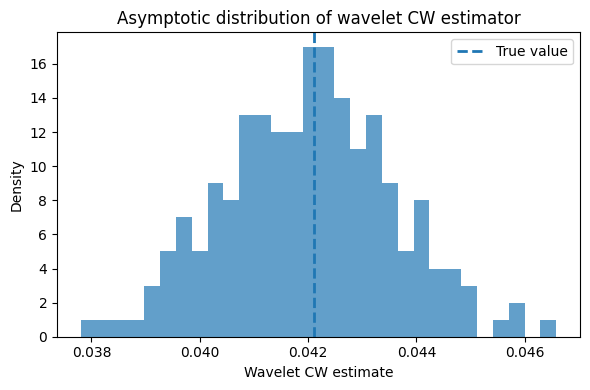

In [8]:
#@title Example: Gaussian location and scale model, dy=2, dz=2
# Be patient, as it takes a while to run

# We actually can compute the exact asymptotic distribution, since we can compute the potential function for this Gaussian example + Wasserstein-2 distance
import numpy as np
from typing import Dict, Tuple


def evaluate_coverage_wavelet_cw(
    R: int = 100,              # number of Monte Carlo repetitions
    B: int = 100,              # bootstrap reps per dataset; 100
    alpha: float = 0.05,
    n: int = 1000,
    m: int = 1000,
    Nz: int = 120,
    Ny: int = 120,
    seed: int = 0,
) -> Dict[str, float]:
    """
    Empirical coverage of bootstrap CI for wavelet-based CW estimator.
    """
    rng_global = np.random.default_rng(seed)

    dy, dz = 2, 2

    # ----- Model parameters (fixed across repetitions) -----
    base  = np.array([0.35, 0.55])
    slope = np.array([[0.20, -0.10],
                      [0.05,  0.15]])

    a = np.array([0.12, -0.08])
    Bmat = np.array([[0.10,  0.04],
                     [0.02,  0.06]])

    Sigma0 = np.array([[0.05**2, 0.0],
                       [0.0,     0.03**2]])

    Sigma1 = np.array([[0.07**2, 0.01*0.07*0.04],
                       [0.01*0.07*0.04, 0.04**2]])

    def mu0(z):
        return base[None, :] + z @ slope.T

    def delta_mu(z):
        return a[None, :] + z @ Bmat.T

    def clip01(x):
        return np.clip(x, 0.0, 1.0)

    # ----- True CW (closed form) -----
    true_cw = closed_form_cw_gaussian_dz2(
        a=a, B=Bmat, Sigma0=Sigma0, Sigma1=Sigma1 # here!!!
    )

    # ----- Estimator configuration (fixed) -----
    scw = SmoothConditionalWasserstein(
        dy=dy,
        dz=dz,
        J_joint=4,
        J_z=6,
        wavelet="db4",
        mode="periodization",
        threshold=None,
        nonnegativity=True,
        renormalize=True,
    )

    cover_pct = 0
    cover_basic = 0
    ci_len_pct = []
    ci_len_basic = []
    bias = []

    # ===============================
    # Monte Carlo loop
    # ===============================
    for r in range(R):
        rng = np.random.default_rng(seed + 1000 * r)

        # Data generation
        Z0 = rng.random((n, dz))
        Z1 = rng.random((m, dz))

        # location mdoel
        Y0 = clip01(
            mu0(Z0) + rng.multivariate_normal(np.zeros(dy), Sigma0, size=n)
        )
        Y1 = clip01(
            mu0(Z1) + delta_mu(Z1)
            + rng.multivariate_normal(np.zeros(dy), Sigma1, size=m)
        )

        # # location + scale model
        # # heteroskedastic scale depending on the first coordinate of Z0
        # gamma = 1.0  # strength of heteroskedasticity
        # z0 = Z0[:, 0]
        # scale0 = np.exp(gamma * (z0 - 0.5))  # shape (n,), positive
        # eps0 = rng.multivariate_normal(np.zeros(dy), Sigma0, size=n)  # (n, dy)
        # eps0 = eps0 * np.sqrt(scale0)[:, None]
        # Y0 = clip01(mu0(Z0) + eps0)
        # z1 = Z1[:, 0]
        # scale1 = np.exp(gamma * (z1 - 0.5))  # shape (m,), positive
        # eps1 = rng.multivariate_normal(np.zeros(dy), Sigma1, size=m)
        # eps1 = eps1 * np.sqrt(scale1)[:, None]
        # Y1 = clip01(mu0(Z1) + delta_mu(Z1) + eps1)


        # Bootstrap CI
        res = bootstrap_wavelet_cw(
            scw=scw,
            Y0=Y0, Z0=Z0,
            Y1=Y1, Z1=Z1,
            B=B,
            alpha=alpha,
            Nz=Nz,
            Ny=Ny,
            seed=seed + r,
        )

        lo_p, hi_p = res.ci_percentile
        lo_b, hi_b = res.ci_basic

        cover_pct += (lo_p <= true_cw <= hi_p)
        cover_basic += (lo_b <= true_cw <= hi_b)

        ci_len_pct.append(hi_p - lo_p)
        ci_len_basic.append(hi_b - lo_b)
        bias.append(res.point_est - true_cw)

        if (r + 1) % 10 == 0:
            print(f"Replication {r+1}/{R} done")

    return {
        "true_CW": true_cw,
        "point_est":  np.array(bias) + true_cw,
        "ci_len_basic":  ci_len_basic,
        "coverage_percentile": cover_pct / R,
        "coverage_basic": cover_basic / R,
        "avg_CI_len_percentile": float(np.mean(ci_len_pct)),
        "avg_CI_len_basic": float(np.mean(ci_len_basic)),
        "bias": float(np.mean(bias)),
        "rmse": float(np.sqrt(np.mean(np.square(bias)))),
    }

results = evaluate_coverage_wavelet_cw(
    R=200, # 200
    B=100, # 100
    n = 3000,
    m = 3000,
    Nz=120,
    Ny=120,
    seed=318,
)
# n, m need to be large, otherwise, significantly biased.

for k, v in results.items():
    print(f"{k}: {v}") # coverage_basic: coverage based on CLT

plt.figure(figsize=(6, 4))
plt.hist(results["point_est"], bins=30, density=False, alpha=0.7)
plt.axvline(results["true_CW"], linestyle="--", linewidth=2, label="True value")

plt.xlabel("Wavelet CW estimate")
plt.ylabel("Density")
plt.title("Asymptotic distribution of wavelet CW estimator")
plt.legend()
plt.tight_layout()
plt.show()

Settings: 3 x 3 x 2 = 18

Sample size: $n = 2000, 4000, 6000$

Dimension:
dy=1, dz=2,
dy=2, dz=1,
dy=2, dz=2,

Model:
location

In [ ]:
pip install dualbounds

In [ ]:
# Import packages
import sys; sys.path.insert(0, "../../../")
import numpy as np
import dualbounds as db
from dualbounds.generic import DualBounds

In [ ]:
R=1

rng_global = np.random.default_rng(seed)
dy, dz = 2, 2

B=100
n = 2000
m = 2000
Nz=120
Ny=120
seed=318

def mu0(z):
    return base[None, :] + z @ slope.T

def delta_mu(z):
    return a[None, :] + z @ Bmat.T

def clip01(x):
    return np.clip(x, 0.0, 1.0)

base  = np.array([0.35, 0.55])
slope = np.array([[0.20, -0.10],
                  [0.05,  0.15]])

a = np.array([0.12, -0.08])
Bmat = np.array([[0.10,  0.04],
                  [0.02,  0.06]])

Sigma0 = np.array([[0.05**2, 0.0],
                    [0.0,     0.03**2]])

Sigma1 = np.array([[0.07**2, 0.01*0.07*0.04],
                    [0.01*0.07*0.04, 0.04**2]])

for r in range(R):
        rng = np.random.default_rng(seed + 1000 * r)

        # Data generation
        Z0 = rng.random((n, dz))
        Z1 = rng.random((m, dz))

        Y0 = clip01(
            mu0(Z0) + rng.multivariate_normal(np.zeros(dy), Sigma0, size=n)
        )
        Y1 = clip01(
            mu0(Z1) + delta_mu(Z1)
            + rng.multivariate_normal(np.zeros(dy), Sigma1, size=m)
        )

        X = np.vstack([Z0, Z1])                      # (n+m, dz)
        W = np.concatenate([np.zeros(n), np.ones(m)]) # (n+m,)
        y = np.vstack([Y0, Y1])
        pis = np.full(n + m, m / (n + m))
        data = {
            "X": X,
            "W": W,
            "y": y,
            "pis": pis,
        }


        # Initialize dual bounds object
        dbnd = DualBounds(
            f=lambda y0, y1, x: np.sum((y0-y1)**2), # the estimand is E[f(y0, y1, x)]
            covariates=data['X'], # n x p covariate matrix
            treatment=data['W'], # n-length treatment vector
            outcome=data['y'], # n-length outcome vector
            propensities=data['pis'], # n-length propensity scores (optional)
            outcome_model='ridge', # description of model for Y | X, W
        )

        dbnd.fit(
        nfolds=5, # number of cross-fitting folds
        alpha=0.05, # nominal level,
        verbose=True # show progress bars
        )
        print(dbnd.results().to_markdown())





ValueError: outcome should be a flat array not a matrix